# Optimisation of problem using 3 algorithms

#### Imports


In [463]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sin

#### Define problem (McCormick function)


In [464]:
problem = lambda x, y: np.sin(x+y) + np.power(x-y, 2) - 1.5*x + 2.5*y + 1

#### Generate 500 random solutions and plot fitness
First, we will generate 500 random solutions uniformly in the range -5 to 5 as suggested as a starting point. Then I calculate the fitness for each of the 500 solutions and plot the solutions vs the fitness on a scatter graph

In [465]:
# Generate 500 random solutions in the range [-5, 5]
x = np.random.uniform(-5, 5, 500)
y = np.random.uniform(-5, 5, 500)
fitness = np.array([(x,y,problem(x, y)) for x, y in zip(x, y)])

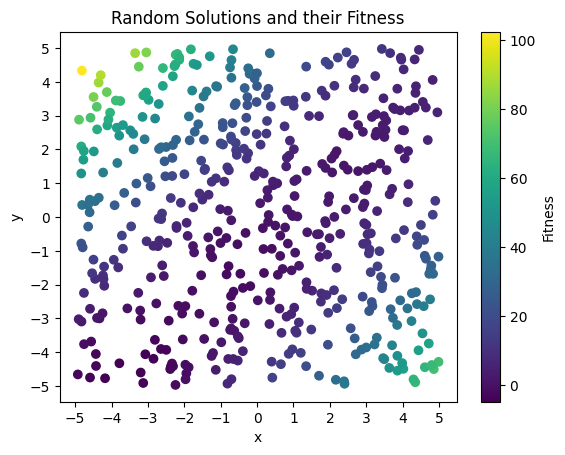

In [ ]:
plt.scatter(x, y, c=fitness[:, 2], cmap='viridis') # Visualise the solutions and their fitnesses
plt.xticks(np.arange(-5, 6, 1))
plt.yticks(np.arange(-5, 6, 1))
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Solutions and their Fitness')
plt.show()

After plotting the 500 random solutions it becomes clear there is a valley of best fitnesses in a diagonal line across the graph. By selecting and replotting the top 100 solutions (by fitness), it is possible to define a smaller search range for the hillclimber and evolutionary algorithms to start at. 

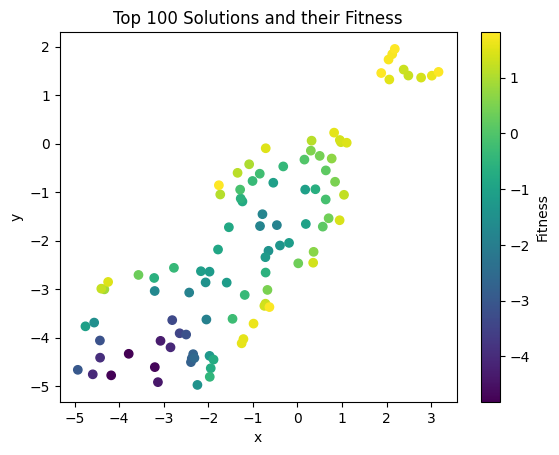

In [467]:
top_100_fitness = fitness[np.argsort(fitness[:, 2])[:100]] # Select the top 100 solutions based on fitness
plt.scatter(top_100_fitness[:, 0], top_100_fitness[:, 1], c=top_100_fitness[:, 2], cmap='viridis')
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Top 100 Solutions and their Fitness')
plt.show()

In [468]:
new_x_min, new_x_max = top_100_fitness[:, 0].min(), top_100_fitness[:, 0].max() # Return the x and y ranges of the top 100 solutions, and the best solution from random sampling
new_y_min, new_y_max = top_100_fitness[:, 1].min(), top_100_fitness[:, 1].max()
best_x_from_random, best_y_from_random, best_fitness = top_100_fitness[0]
print(f"Best solution from random sampling: x={best_x_from_random:.2f}, y={best_y_from_random:.2f}, fitness={best_fitness:.2f}")
pd.DataFrame(
    {"min": [new_x_min, new_y_min], "max": [new_x_max, new_y_max]},
    index=["X", "Y"],
)

Best solution from random sampling: x=-3.79, y=-4.33, fitness=-4.82


,min,max
X,-4.927925,3.167534
Y,-4.971285,1.950276


#### Define hillclimber algorithm using guassian mutation
The hillclimber function accepts an initial starting point, number of iterations, the problem and the mutation function.

I am using guassian mutation as a lambda which works by performing a random mutation from a normal distribution centered around 0 to the input.

The function starts by setting initial points as the best_x and best_y and evaluating initial fitness. Then for each iteration it applies a random mutation to x and y, recalculates the fitness, stores the solution and if the fitness is higher, it sets best_x, best_y and current fitness to the new solution.

After all iterations have completed, the best solution and all solutions are returned.

To help with evaluating the algorithm, I have defined a helper function evaluate_hill_climber which simplifies running the algorithm repeatedly to evaluate the reliability.

The visualise function produces 3 graphs:
1. Solutions vs fitness (Shows how the algorithm moves towards the best solution and creates a grouping around it)
2. Fitness vs iterations (Shows how the solution improves every iteration, and shows the ideal stopping point)
3. Final best fitness per 100 runs (Shows the reliability of algorithm, only shown when data is from multiple runs) 

In [469]:
gmutate = lambda x: x + np.random.normal(0, 0.1) # Mutates x by random value from normal distribution around 0 with scale of 0.1

In [470]:
def hillclimb(x: float, y: float, fitness_func: callable, iterations: int) -> tuple[float, float, float, np.ndarray]: # Perform the hill climbing algorithm starting from (x, y) for a given number of iterations, using the provided fitness function
    best_x, best_y = x, y # Start with the initial solution
    current_fitness = fitness_func(best_x, best_y) # Evaluate the fitness of the initial solution
    solutions = np.array([[best_x, best_y, current_fitness]])
    for _ in range(iterations): # For each iteration, mutate the current solution and evaluate the new fitness
        new_x = gmutate(best_x)
        new_y = gmutate(best_y)
        new_fitness = fitness_func(new_x, new_y)
        solutions = np.append(solutions, [[new_x, new_y, new_fitness]], axis=0) # Store the new solution and its fitness

        if new_fitness < current_fitness: # If the new solution is better, update the best solution and fitness
            best_x, best_y, current_fitness = new_x, new_y, new_fitness

    return best_x, best_y, current_fitness, solutions # Return the best solution and its fitness, along with all solutions evaluated

In [471]:
def evaluate_hill_climber(iterations: int, fitness_func: callable, runs: int = 1, x_range: tuple = (-5, 5), y_range: tuple = (-5, 5)) -> tuple[float, float, float, np.ndarray, list]:
    fitnesses = []
    for i in range(runs):
        init_x, init_y = np.random.uniform(x_range[0], x_range[1]), np.random.uniform(y_range[0], y_range[1])
        best_x, best_y, best_fitness, solutions = hillclimb(init_x, init_y, fitness_func, iterations)
        fitnesses.append((i, best_fitness))
    return best_x, best_y, best_fitness, solutions, fitnesses

In [472]:
def visualise_hill_climbing_results(solutions: np.ndarray, fitnesses: list, is_multiple_runs: bool = False) -> tuple[plt.Figure, np.ndarray]:
    unique_fitnesses, counts = np.unique([np.round(f[1],1) for f in fitnesses], return_counts=True)
    fig, axs = plt.subplots(3 if is_multiple_runs else 2, 1, figsize=(5, 8) if is_multiple_runs else (5, 6))
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap="viridis")
    fig.colorbar(axs[0].collections[0], label="Fitness")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[0].set_title("Hill Climbing Solutions and their Fitness")

    axs[1].plot(solutions[:, 2])
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Fitness")
    axs[1].set_title("Fitness over Iterations")
    if is_multiple_runs:
        axs[2].set_xlabel("Run")
        axs[2].set_ylabel("Best Fitness")
        axs[2].set_title("Best Fitness across Multiple Runs of the Hill Climbing Algorithm")
        axs[2].scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
        for f, count in zip(unique_fitnesses, counts):
            axs[2].text(100, f, f"      {count} runs", va="center")
        axs[2].set_ylim(-6, 6)
    return fig, axs

#### Run hillclimber and plot fitness per solution and over time
To run hillclimber, I select a random start x and y from a uniform distribution between -5 and 5. Hillclimber is then ran with 200 iterations to find the best solution.

On one run, the output is `Best solution: x=-0.5765798874513859, y=-1.542185000635579, fitness=-1.9117840051283141`, and that the fitness is stable after approximately 120 iterations. 

This solution (-0.5423, -1.548, fitness -1.913) is very close to the global minimum for the function (-0.54719, -1.54719, fitness -1.9133) when evaluated on the standard search space (x -1.5 to 4, y -3 to 4), however, on the expanded search space we are using here (-5, 5), it is not the global minimum. 

This shows that the hillclimber is getting stuck in a local optima.

Testing larger number of iterations (up to 20,000) shows that the algorithm does not recover from being stuck in the local optima (likely due to the low mutation making it unable to climb from a local optima found from the initial x and y).

Best solution: x=-3.683261136852563, y=-4.68032915549012, fitness=-5.054722034548254


/tmp/ipykernel_26759/1866241085.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


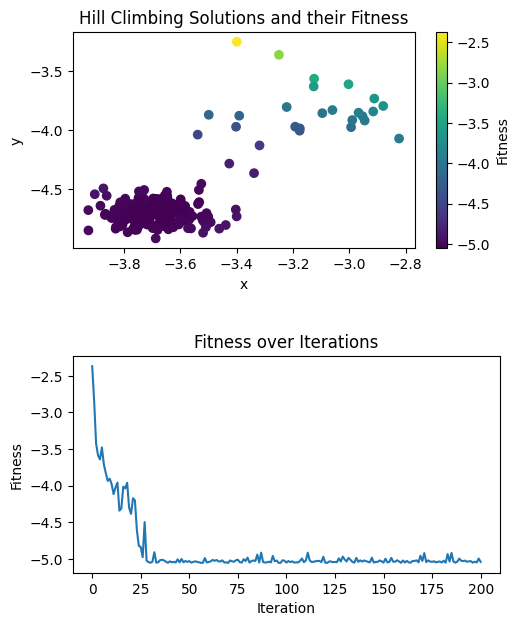

In [473]:
# Run hill climbing once inside the wide search space
best_x, best_y, best_fitness, solutions, fitnesses = evaluate_hill_climber(iterations=200, fitness_func=problem, runs=1, x_range=(-5, 5), y_range=(-5, 5))
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")
fig, axs = visualise_hill_climbing_results(solutions, fitnesses, is_multiple_runs=False)
fig.show()

#### Evaluate reliability / reproducability of hillclimber
To evaluate the algorithm, I am running it 100 times to produce a graph displaying the final best fitness for each run.

This shows that the hillclimber algorithm when run in the wide search space (-5,5), only finds the global optimum 18/100 runs. This is due to it getting stuck in local optimas very commonly and being unable to climb from them.

/tmp/ipykernel_26759/2209007856.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


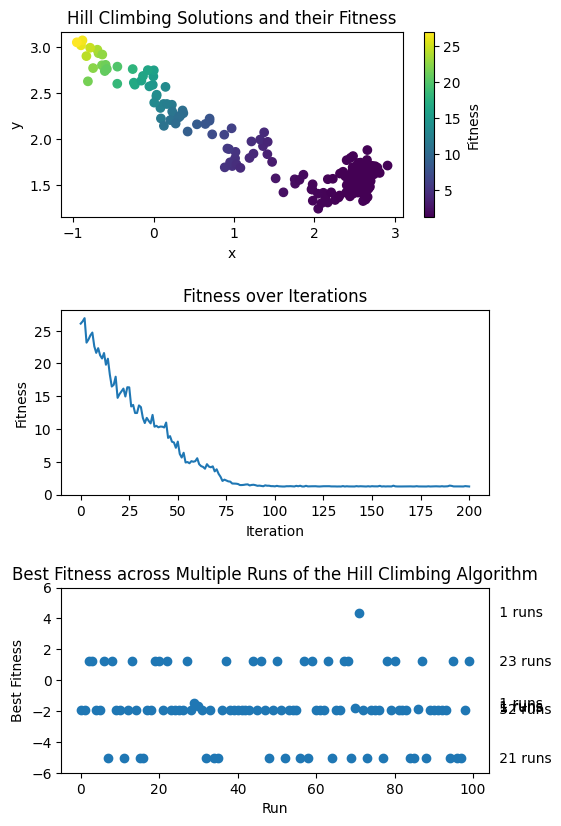

In [474]:
# Run hill climbing 100 times with random initial solutions in the wide search space, and visualise the results
best_x, best_y, best_fitness, solutions, fitnesses = evaluate_hill_climber(iterations=200, fitness_func=problem, runs=100)
fig, axs = visualise_hill_climbing_results(solutions, fitnesses, is_multiple_runs=True)
fig.show()

#### Evaluate hillclimber inside a limited search space
Instead of using the wide search space, if we instead start the search in a much smaller space (taken from the top 100 of the 500 random solutions), then the algorithm is able to find the global optimum solution 30/100 runs. 

This shows that the hillclimber algorithm benefits greatly from a tighter start solution

/tmp/ipykernel_26759/993635154.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


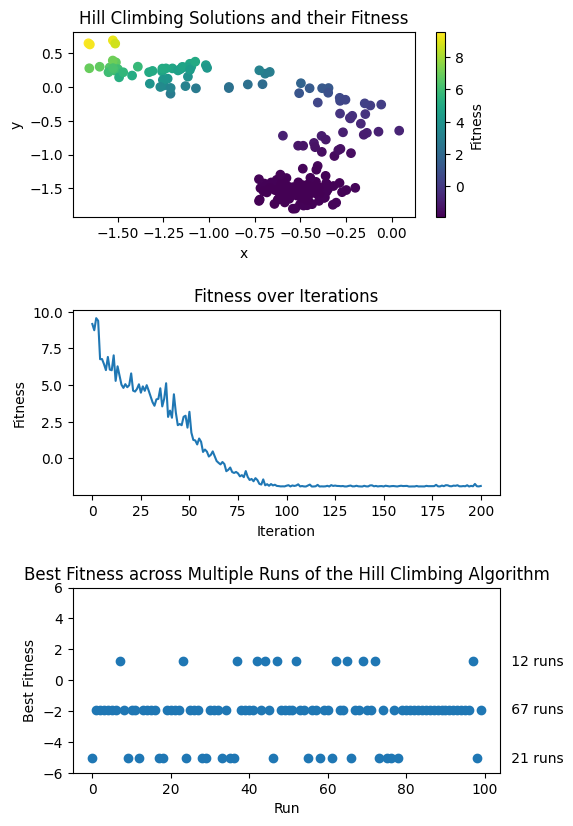

In [475]:
best_x, best_y, best_fitness, solutions, fitnesses = evaluate_hill_climber(iterations=200, fitness_func=problem, runs=100, x_range=(new_x_min, new_x_max), y_range=(new_y_min, new_y_max))
fig, axs = visualise_hill_climbing_results(solutions, fitnesses, is_multiple_runs=True)
fig.show()

#### Define evolutionary algorithm
First, I define mutate_and_eval, a helper function which will mutate the input values and evaluate the new values returning new_x, new_y, and new_fitness.

The evolutionary algorithm works by generating a population of `pop_size` with solutions uniformally distributed between -5 and 5, then fitness is calculated for each member. For each generation, each member is mutated, evaluated and added to the population. Then the population is pruned removing the bottom `pop_size` elements, and the best fitness per generation is stored.

Finally, the best solution overall is recorded and all results are returned.


In [476]:
def mutate_and_eval(x: float, y: float, fitness_func: callable) -> tuple: # Mutate x and y, then evaluate fitness
    new_x = gmutate(x)
    new_y = gmutate(y)
    new_fitness = fitness_func(new_x, new_y)
    return new_x, new_y, new_fitness

In [ ]:
def evolutionary_algorithm(pop_size: int, generations: int, fitness_func: callable, x_search_range: tuple = (-5, 5), y_search_range: tuple = (-5, 5)) -> tuple: # Evolutionary algorithm with given population size and number of generations
    pop = np.random.uniform((x_search_range[0], y_search_range[0]), (x_search_range[1], y_search_range[1]), (pop_size, 2)) # Initialise population with random solutions in the given search range
    fitness = fitness_func(pop[:, 0], pop[:, 1]).reshape(-1, 1) # Evaluate fitness of initial population and flatten array
    population = np.hstack((pop, fitness))
    best_fitness_per_gen = np.array([np.min(population[:, 2])]) 
    for _ in range(generations):
        children = np.array([mutate_and_eval(x, y, fitness_func) for x, y, _ in population]) # mutate each parent to create child and evaluate fitness
        population = np.vstack((population, children)) # combine parents and children
        population = population[np.argsort(population[:, 2])][:pop_size] # select top pop_size elements
        best_fitness_per_gen = np.append(best_fitness_per_gen, population[0, 2]) 
    best_solution = population[0]
    return best_solution[0], best_solution[1], best_solution[2], population, best_fitness_per_gen

In [478]:
def visualise_evolutionary_results(solutions: np.ndarray, best_fitness_per_gen: np.ndarray) -> tuple[plt.Figure, np.ndarray]: # Visualise the results of the evolutionary algorithm, showing the solutions and their fitnesses, and the best fitness over generations
    fig, axs = plt.subplots(2)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap='viridis')
    fig.colorbar(axs[0].collections[0], label='Fitness')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    axs[0].set_title('Evolutionary Algorithm Solutions and their Fitness')
    axs[1].plot(best_fitness_per_gen)
    axs[1].set_xlabel('Generation')
    axs[1].set_ylabel('Best Fitness')
    axs[1].set_title('Best Fitness over Generations')
    axs[1].set_xticks(np.arange(0, len(best_fitness_per_gen)+1, 5))
    return fig, axs

#### Run evolutionary algorithm using 20 generations of 70 children
Running the evolutionary algorithm with 20 generations of 70 children finds the global minimum for our large search space (-5 to 5), which the hillclimber did not. This is due to the evolutionary algorithm having a large population spread which makes it much more resilient to local optimas. 

The choice of 20 generations with a population size of 70 was found by plotting fitness over generations for a set population size and reducing generations closer to the stagnant point. The algorithm was then run 100 times with the same parameters to plot the stability. 

Using a smaller population and number of generations still finds the correct answer, however, when ran 100 times it is possible to see that it gets caught in a local optima in a large percentage of runs. 

By tuning both the generation count and population size, I found that 20 generations of 70 children was a good choice as it only got stuck in a local optima in ~10/500 runs. It would be possible to increase generations and population size to reduce this even further, however, this would increase execution time so it is a trade off between performance and accuracy / stability

Best solution: x=-3.6874813951665146, y=-4.687964355292473, fitness=-5.054813401371413


/tmp/ipykernel_26759/1548239502.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


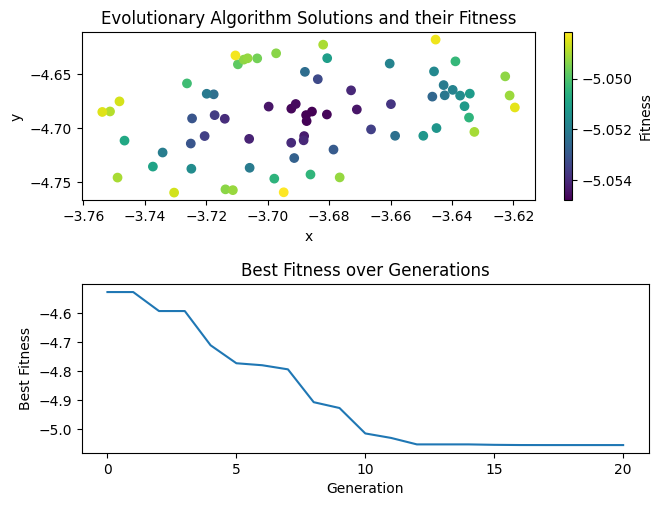

In [479]:
best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(-5, 5), y_search_range=(-5, 5))
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")
fig, axs = visualise_evolutionary_results(solutions, best_fitness_per_gen)
fig.show()

Best solution: x=-3.692347786772404, y=-4.6803470472854976, fitness=-5.054661245610999


/tmp/ipykernel_26759/2630312020.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


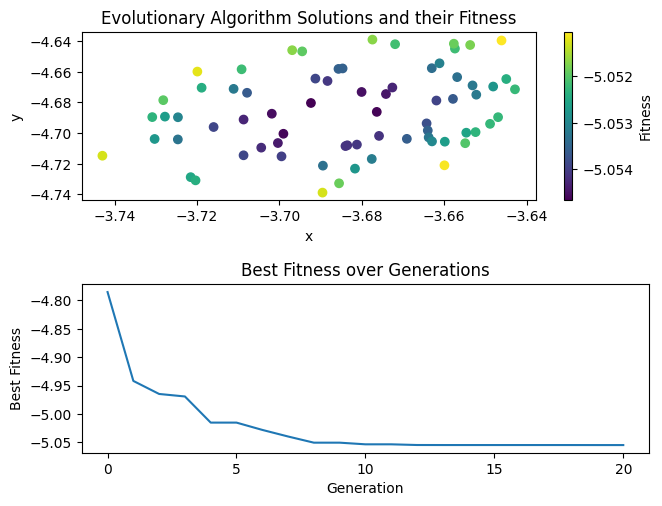

In [480]:
best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(new_x_min, new_x_max), y_search_range=(new_y_min, new_y_max))
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")
fig, axs = visualise_evolutionary_results(solutions, best_fitness_per_gen)
fig.show()

#### Run evolutionary algorithm 500 times to evaluate stability

By running the evolutionary algorithm 500 times with the same population and generation size (once within wide search space, and once within the limited space), we can see the reliability of the algorithm. 

When run in the wide search space, the algorithm finds the global optima ~490/500 times, which means it is very reproducible and is very good at solving the McCormick function. 

When run in the limited search space, the algorithm finds the global optima in less generations and finds the optima in ~499/500 times, which is a good improvement over the wide search space. This would be useful if the results are needed to be very reproducible, however it requires the testing of 500 random samples before, which will increase overall complexity and computation time. 

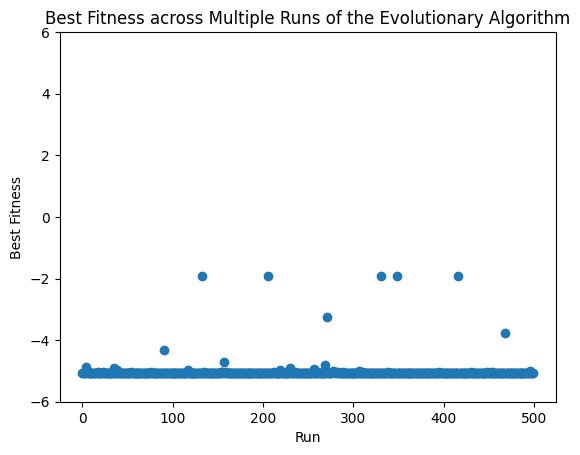

In [481]:
fitnesses = []
for i in range(500):
    best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(-5, 5), y_search_range=(-5, 5))
    fitnesses.append((i, best_fitness))
plt.scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
plt.ylim(-6, 6)
plt.xlabel('Run')
plt.ylabel('Best Fitness')
plt.title('Best Fitness across Multiple Runs of the Evolutionary Algorithm')
plt.show()

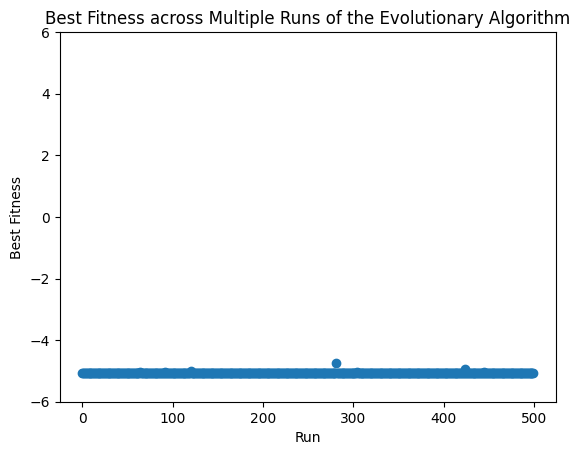

In [482]:
fitnesses = []
for i in range(500):
    best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem, x_search_range=(new_x_min, new_x_max), y_search_range=(new_y_min, new_y_max))
    fitnesses.append((i, best_fitness))
plt.scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
plt.ylim(-6, 6)
plt.xlabel('Run')
plt.ylabel('Best Fitness')
plt.title('Best Fitness across Multiple Runs of the Evolutionary Algorithm')
plt.show()

In summary,

The hillclimber algorithm is very fast and does find an optimum in the whole search space, however, it very often gets stuck in a local optimum and only correctly finds the global optimum in the wide search space on approximately 20% of runs. This algorithm would be useful if finding the global optimum is not strictly necessary, and would benefit greatly from being given a more limited search space (as shown by the result of running in the space of the top 100 solutions from the random generations).

The evolutionary algorithm finds the global optimum very quickly, often stablising at 12 generations. It correctly finds the global optimum in the search space 98% of runs when in the wide search space. It is better at escaping local optimums due to the high spread of initial population over the search space. In the limited search space from the top 100 of 500 random generations, it becomes even more reliable with only 1/500 runs producing a very slightly suboptimal result. 

Overall, this shows hillclimber is very dependent on the initial random start and converges quickly, whereas the evolutionary algorithm takes longer to converge but isn't dependent on a single start value due to its significantly more diverse population. 

I would use the evolutionary algorithm with the wide search space as the best overall solution as it produces a very reproducible result and does not prerequire the testing of 500 random solutions (as needed for using in a limited search space).